(prob:rare-events:power-law)=
# Power-law distributions

Power-law distributions are an extreme case of [heavy-tailed distributions](prob:rare-events:heavy-tailed). As an example, the right tail of a power-law distribution decays as $x^\alpha$, with $\alpha < 0$, for $x \rightarrow +\infty$.

**todo** Examples of systems with power-law distributions, universality and absence of scales
- ...
- [Inertial scales in turbulence (Kolomogorov)](https://basics2022.github.io/bbooks-fluid-mechanics/polimi/fluidmechanics-ita/template/capitoli/10_turbolenza/kolmogorov.html)
- ...


## Example: three different coin-flip games

*Head or Tail* with a fair coin, with different returns and termination events:

1. $100$ tosses of a coin, every $H$ gives you $1\$$. The probability distribution of the total return is the [binomial distribution](). With the definition of a Bernoulli random variable $X_i = 1$ for $H$, $X_i = 0$ for $T$ with even probability, the amount at the end of the game, after $n=100$ tosses, reads

    $$w_{end} = \sum_{i=1}^n X_i \cdot 1\$ \ .$$

2. $100$ tosses, an $H$ gives you $g=+10\%$ gain a $T$ produces a $\ell=-10\%$ loss of the amount you have. At any coin toss, you bet eveything you have. This problem looks like [compounding in investing]()[^kelly-criterion]. Starting with $r_0 = 1\$$, the amount at the end of the game, after $n$ tosses, reads

    $$w_{end} = w_0 \prod_{i=1}^n ( 1 + g )^{X_i} ( 1 + \ell )^{1 - X_i}  \ . $$

[^kelly-criterion]: The probability distribution of the total return can be easily derived withminor modifications from the derivation of the [Kelly criterion](https://basics2022.github.io/bbooks-financial-edu/code/notebooks/rebalancing_intro.html), Example 10.3, an optimality criterion for this game, if you can choose the fraction of the amount you have for betting, given the gain and loss.

3. $100$ tosses, getting $H$ you win $g=+10\%$, getting $T$ you win nothing and the game stops: first $T$ is the termination event; starting with $1\$$, after the $n^{th}$ $H$ in a row, you have $1\$ \cdot 1.1^n$. The amount at the end of the game reads

   $$w_{end} = 
   \begin{cases}
      w_0 \cdot (1+g)^{n_H}  & \text{with probability $2^{-1-n_H}$ for $n_H < n_{tosses}$} \\
      w_0 \cdot (1+g)^{n_H}  & \text{with probability $2^{-n_{tosses}}$ for $n_H = n_{tosses}$}
   \end{cases}$$

   being $n_H$ the number of $H$ in a row. If $n_H$ is constrained to be $\le n_{tosses} = 100$, the probability of getting exactly $99$ or $100$ $H$ in a row is the same; if $n_H$ is not constrained, $w_{end} = w_0 \cdot (1+g)^{n_H}$, for all $n_H \ge 0$, with $p(n_H) = \frac{1}{2^{1+n_H}}$.

0 30


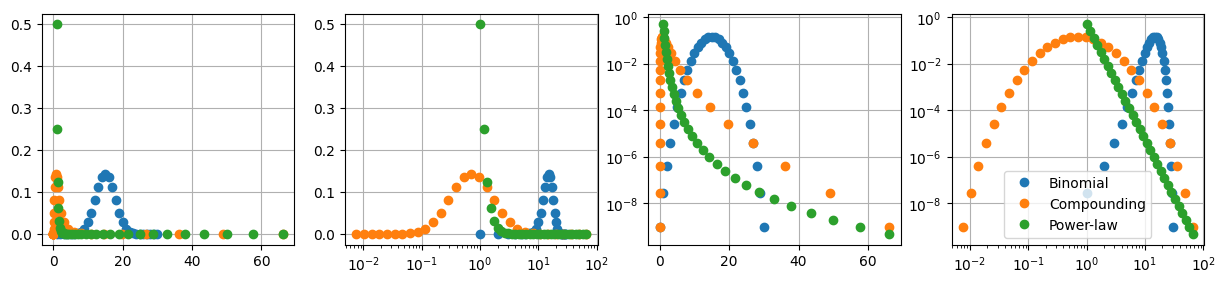

In [27]:
%reset -f
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

n_tosses = 30
p_head = .5

#> 1.Binomial distribution
lb, ub = sp.stats.binom.support(n_tosses, p_head)
xv_binom = np.arange(lb, ub+1)
p_binom = sp.stats.binom.pmf(xv_binom, n_tosses, p_head)
print(lb, ub)

#> 2. Compounding
gain, loss = .15, -.15
nv = np.arange(0, n_tosses+1)
xv_comp = np.array([ (1.+gain)**n * (1.+loss)**(n_tosses-n) for n in nv])
# p_binom = sp.stats.binom.pmf(xv_binom, n_tosses, p_head)


#> 3. Power-law distibution
xv_power = (1+gain)**nv
p_power = 2.**(-1.-nv)

fig, ax = plt.subplots(1,4, figsize=(15, 3))
ax[0].plot(xv_binom, p_binom, 'o')
ax[0].plot(xv_comp , p_binom, 'o')
ax[0].plot(xv_power, p_power, 'o')

ax[1].semilogx(xv_binom, p_binom, 'o')
ax[1].semilogx(xv_comp , p_binom, 'o')
ax[1].semilogx(xv_power, p_power, 'o')

ax[2].semilogy(xv_binom, p_binom, 'o')
ax[2].semilogy(xv_comp , p_binom, 'o')
ax[2].semilogy(xv_power, p_power, 'o')

ax[3].loglog(xv_binom, p_binom, 'o', label='Binomial')
ax[3].loglog(xv_comp , p_binom, 'o', label='Compounding')
ax[3].loglog(xv_power, p_power, 'o', label='Power-law')
ax[3].legend()

for i in np.arange(4): ax[i].grid()


- Binomial distribution becomes approximately normal as $n$ increases,

   $$p_1(x) \sim \mathscr{N}(\mu_n, \sigma_n) \sim \text{exp} \left[ -\frac{(x-\mu_n)^2}{2 \sigma^2_n} \right]$$

- Compounding produces a distribution that becomes approximately log-normal as $n$ increases...

- Power-law has probability $p_3(n)$ and outcome $x_3(n)$

   $$p_3(n) = 2^{-1-n} \quad , \quad x_3(n) = 2^n \ ,$$

   and thus $p_3(x) = \frac{1}{2} x^{-1} \ .$ Taking the logarithm of this expression, a 1-degree polynomial relation between logarithms of $p$ and $x$ is obtained, $\ln p_3 = - \ln 2 - \ln x$.

## Integrability of tails, existence of moments

```{admonition} Power-law *pdf* and existence of moments.
:class: tip

A power-law density $p(x) \propto x^{\alpha}$ defined on an unbounded domain is normalizable only for $\alpha < -1$. For $\alpha \ge -1$, normalization requires the introduction of an upper cutoff.

On unbounded domains, the first $n$ moments exist if $\alpha > -n$.

```



Let the tail of the distribution follow a power law $p(x) \sim x^\alpha$ for $x > x_0$. On finite domains, no problem exists. On **infinite domains**, in order for $p(x)$ to represent a probability density function, $\alpha < -1$, as

$$\int_{x = x_0}^{+\infty} p(x) \, dx = \int_{x = x_0}^{+\infty} x^{\alpha} \, dx = \left.\frac{1}{1+\alpha} x^{1+\alpha} \right|_{x_0}^{+\infty} = 
\begin{cases} 
  -\frac{1}{1+\alpha} x_0 \ \text{ finite } & , \ \alpha < -1 \\
   \infty & , \ \alpha \ge -1 
\end{cases}
$$

Even if the function $p(x)$ is a *pdf*, $\alpha < -1$, moments may diverge.

**Expected value.**

$$\mu = \int_{\Omega} x \, p(x) \, dx$$

if $\Omega$ has no upper limit, the integral converges only if

$$\int_{x_0}^{+\infty} x \, p(x) \, dx \sim \int_{x_0}^{+\infty} x \cdot x^{\alpha} \, dx = \int_{x_0}^{+\infty} x^{\alpha+1} \, dx \ ,$$

converges, i.e. for $\alpha < -2$

**Variance.** Analogously, the distribution has finite variance if $\alpha < -3$.

## Failure of CLT



Using transformation of probability functions to sample a r.v. with power-law distribution $p(x) = c x^{-\alpha}$, $x \in [x_0, +\infty)$, starting from sampling of a r.v. with uniform distribution $u(x)=1$, $x \in [0,1]$.

**Normalization.** For $\alpha > 1$,

$$1 = \int_{t=x_0}^{+\infty} p(x) \, dx = \int_{t=x_0}^{+\infty} c x^{-\alpha} \, dx = \frac{c}{1-\alpha} \left.\left[ x^{1-\alpha} \right]\right|_{x_0}^{+\infty} = \frac{c}{\alpha - 1} x_0^{-(\alpha-1)}  \ , $$

and thus $c = (\alpha - 1 ) x_0^{\alpha-1}$, and the probability density function reads

$$p(x) = (\alpha - 1)x_0^{\alpha-1} x^{-\alpha} \ , \quad x \ge x_0 \ .$$

**Expected value.**

$$\begin{aligned}
  \mu 
  & = \int_{x=x_0}^{+\infty} x \, p(x) \, dx =  \\
  & = \int_{x=x_0}^{+\infty} (\alpha-1) x_0^{\alpha-1} x \cdot x^{-\alpha} \, dx = \\
  & =  \left. (\alpha-1) x_0^{\alpha-1} \frac{1}{-\alpha+2} x^{-\alpha+2} \right|_{x_0}^{+\infty}
\end{aligned}$$

converges for $\alpha > 2$,

$$\mu = \frac{\alpha-1}{\alpha-2} x_0 \  .$$

As an example, with $\alpha = 1.5$ the expected value is not defined; with $\alpha = 2.5$, $\mu_{\alpha=2.5} = \frac{1.5}{0.5} x_0 = 3 x_0$.

**Cumulative probability function.**

$$P(x) = \int_{t=x_0}^{x} p(t) \, dt = \int_{t=x_0}^{x} c t^{-\alpha} \, dt = (\alpha - 1) x_0^{\alpha-1} \left. \frac{t^{1-\alpha}}{1-\alpha} \right|_{x_0}^{x} = 1 - \left( \frac{x_0}{x} \right)^{\alpha-1}$$

As sampling from a uniform distribution requires the equality of the cumulative probability densities, and $U(x) = x$, **todo** *quite bad notation* it follows

$$P(X) = U \sim \text{Uniform}(0,1)$$

and thus

$$U = 1 - \left( \frac{x_0}{X} \right)^{\alpha-1}$$

or

$$X = x_0 \, \left( 1 - U \right)^{-\frac{1}{\alpha - 1}}$$

### Power-law with $\alpha = 1.5$

In [95]:
%reset -f
import numpy as np

#> Power-law
x0 = 1.
alpha = 1.5

#> N.samples
n_samples = int(1e+4)
n_reals = 200

#> Uniform random number generator
rng = np.random.default_rng()
rng_uniform_fun =  lambda n: rng.uniform(.0,1., n)

um, xm = [], []

for i_real in np.arange(n_reals):
    #> Samples from the r.v. with the uniform distribution
    u = rng_uniform_fun(n_samples)

    #> Samples from the r.v. with power-law distribution
    x = x0 * ( 1. - u )**(-1./(alpha-1.))

    um += [ u ]
    xm += [ x ]

xm = np.array(xm)

In [96]:
# print(xm)
# print(np.shape(np.cumsum(xm, axis=0)))

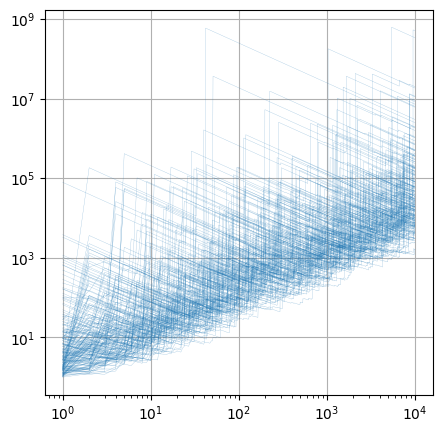

In [94]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(5,5))
# ax.plot( np.cumsum(xm.T, axis=0) / np.arange(1,n_samples+1)[:, np.newaxis], color=plt.cm.tab10.colors[0], lw=.5 )
ax.loglog( np.arange(1, n_samples+1),
           np.cumsum(xm.T, axis=0) / np.arange(1,n_samples+1)[:, np.newaxis], 
           color=plt.cm.tab10.colors[0], 
           alpha=.5,
           lw=.2 )
ax.grid()

plt.show()

### Power-law with $\alpha = 2.5$

In [100]:
%reset -f
import numpy as np

#> Power-law
x0 = 1.
alpha = 2.5

#> N.samples
n_samples = int(1e+5)
n_reals = 200

#> Uniform random number generator
rng = np.random.default_rng()
rng_uniform_fun =  lambda n: rng.uniform(.0,1., n)

um, xm = [], []

for i_real in np.arange(n_reals):
    #> Samples from the r.v. with the uniform distribution
    u = rng_uniform_fun(n_samples)

    #> Samples from the r.v. with power-law distribution
    x = x0 * ( 1. - u )**(-1./(alpha-1.))

    um += [ u ]
    xm += [ x ]

xm = np.array(xm)

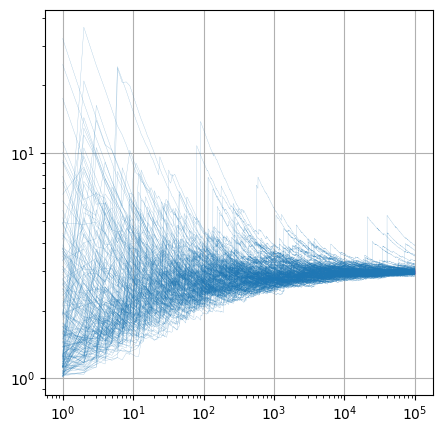

In [101]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1, figsize=(5,5))
# ax.plot( np.cumsum(xm.T, axis=0) / np.arange(1,n_samples+1)[:, np.newaxis], color=plt.cm.tab10.colors[0], lw=.5 )
ax.loglog( np.arange(1, n_samples+1),
           np.cumsum(xm.T, axis=0) / np.arange(1,n_samples+1)[:, np.newaxis], 
           color=plt.cm.tab10.colors[0], 
           alpha=.5,
           lw=.2 )
ax.grid()

plt.show()

**todo** Plot
- max $M_n$ vs. sum $S_n$, as the ratio $\frac{M_n}{S_n}$ as max dominates sum for heavy-tailed distributions
- quantile trajectories

**todo** Let's check the following results, with Law of Large Numbers (LLN) and Central Limit Theorem (CLT)

| (\alpha)         | Mean     | Variance | Sample mean behavior                                                          |
| ---------------- | -------- | -------- | ----------------------------------------------------------------------------- |
| $\alpha>3$       | Finite   | Finite   | **Classical LLN & CLT** (Gaussian)                                            |
| $2<\alpha \le 3$ | Finite   | Infinite | **LLN holds**, but **CLT replaced by stable law** (non-Gaussian fluctuations) |
| $\alpha \le 2$   | Infinite | Infinite | **LLN fails**, sample mean diverges; dominated by extreme events              |
